In [1]:
import yaml
import torch
import numpy as np
from einops import rearrange
from matplotlib import pyplot as plt
from typing import Sequence

In [2]:
rootdir = '/home/ca550013/Master-Thesis/Projects/BraTS3DDiff'

Load DataModule and Data Loaders

In [3]:
from src.datasets.brats_datamodule_viz import BraTSDataModule

In [4]:
with open(f"{rootdir}/configs/data/brats23_patch_tumor_classify_diffusion.yaml") as f:
    cfg = yaml.safe_load(f)
cfg.pop('_target_')
cfg['data_dir'] = f"{rootdir}/data/BraTS-Data/BraTS2023-GLI"
cfg['batch_size'] = 1
datamodule = BraTSDataModule(**cfg)

train_data = datamodule.data_train
test_data = datamodule.data_test
val_data = datamodule.data_val



/home/ca550013/Miniconda3-New/envs/bratseg/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [5]:
data = test_data.__getitem__(5)
data.keys()

dict_keys(['image', 'mask', 'orig_image', 'foreground', 'orig_foreground', 'orig_mask', 'foreground_start_coord', 'foreground_end_coord'])

Plotting tools

In [31]:
from matplotlib import pyplot as plt

def imshows(ims: list[dict]):
    nrow = len(ims)
    ncol = len(ims[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3, nrow * 3), facecolor="white")
    for i, im_dict in enumerate(ims):
        for j, (title, im) in enumerate(im_dict.items()):
            if isinstance(im, torch.Tensor):
                im = im.detach().cpu().numpy()
            if len(ims) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.set_title(f"{title}\n{im.shape}")
            ax.grid(True)
            im_show = ax.imshow(im)

            fig.colorbar(im_show, ax=ax)
    plt.tight_layout()


def transform_imgs(data: dict, depth:int=None, label_regions=['WT','TC', 'ET'], patch_sizes:list=None, key='', incl_fg=True):
    #Transforms a dict of 3D images to 2D
    new_data = {}
    img_key, label_key, fg_key = [f"{key}{x}" for x in ['image', 'mask', 'foreground']]
    
    image = data[img_key]
    if depth is None:
        depth = image.shape[-1] // 2
    new_data[img_key] = image[0,:,:,depth]

    label = data[label_key][:,:,:,depth]
    labels = {f"{key}label_{label_regions[i]}": label[i,:,:] for i in range(len(label_regions))}
    new_data.update(labels)

    if incl_fg:
        new_data[fg_key] = data[fg_key][0,:,:,depth]

    if ('patch_tumor_labels' in data.keys()) and (patch_sizes is not None):
        for patch_size in patch_sizes:
            patch_labels = data['patch_tumor_labels'][patch_size]
            new_data[f'patch_labels_{patch_size}'] = patch_labels[0,:,:,patch_labels.shape[-1] // 2]

    return new_data   

Display Image and Label Pairs (Train/ Val) \
CropForeground -> RandSpatialCrop -> SpatialPad -> 128x128x128

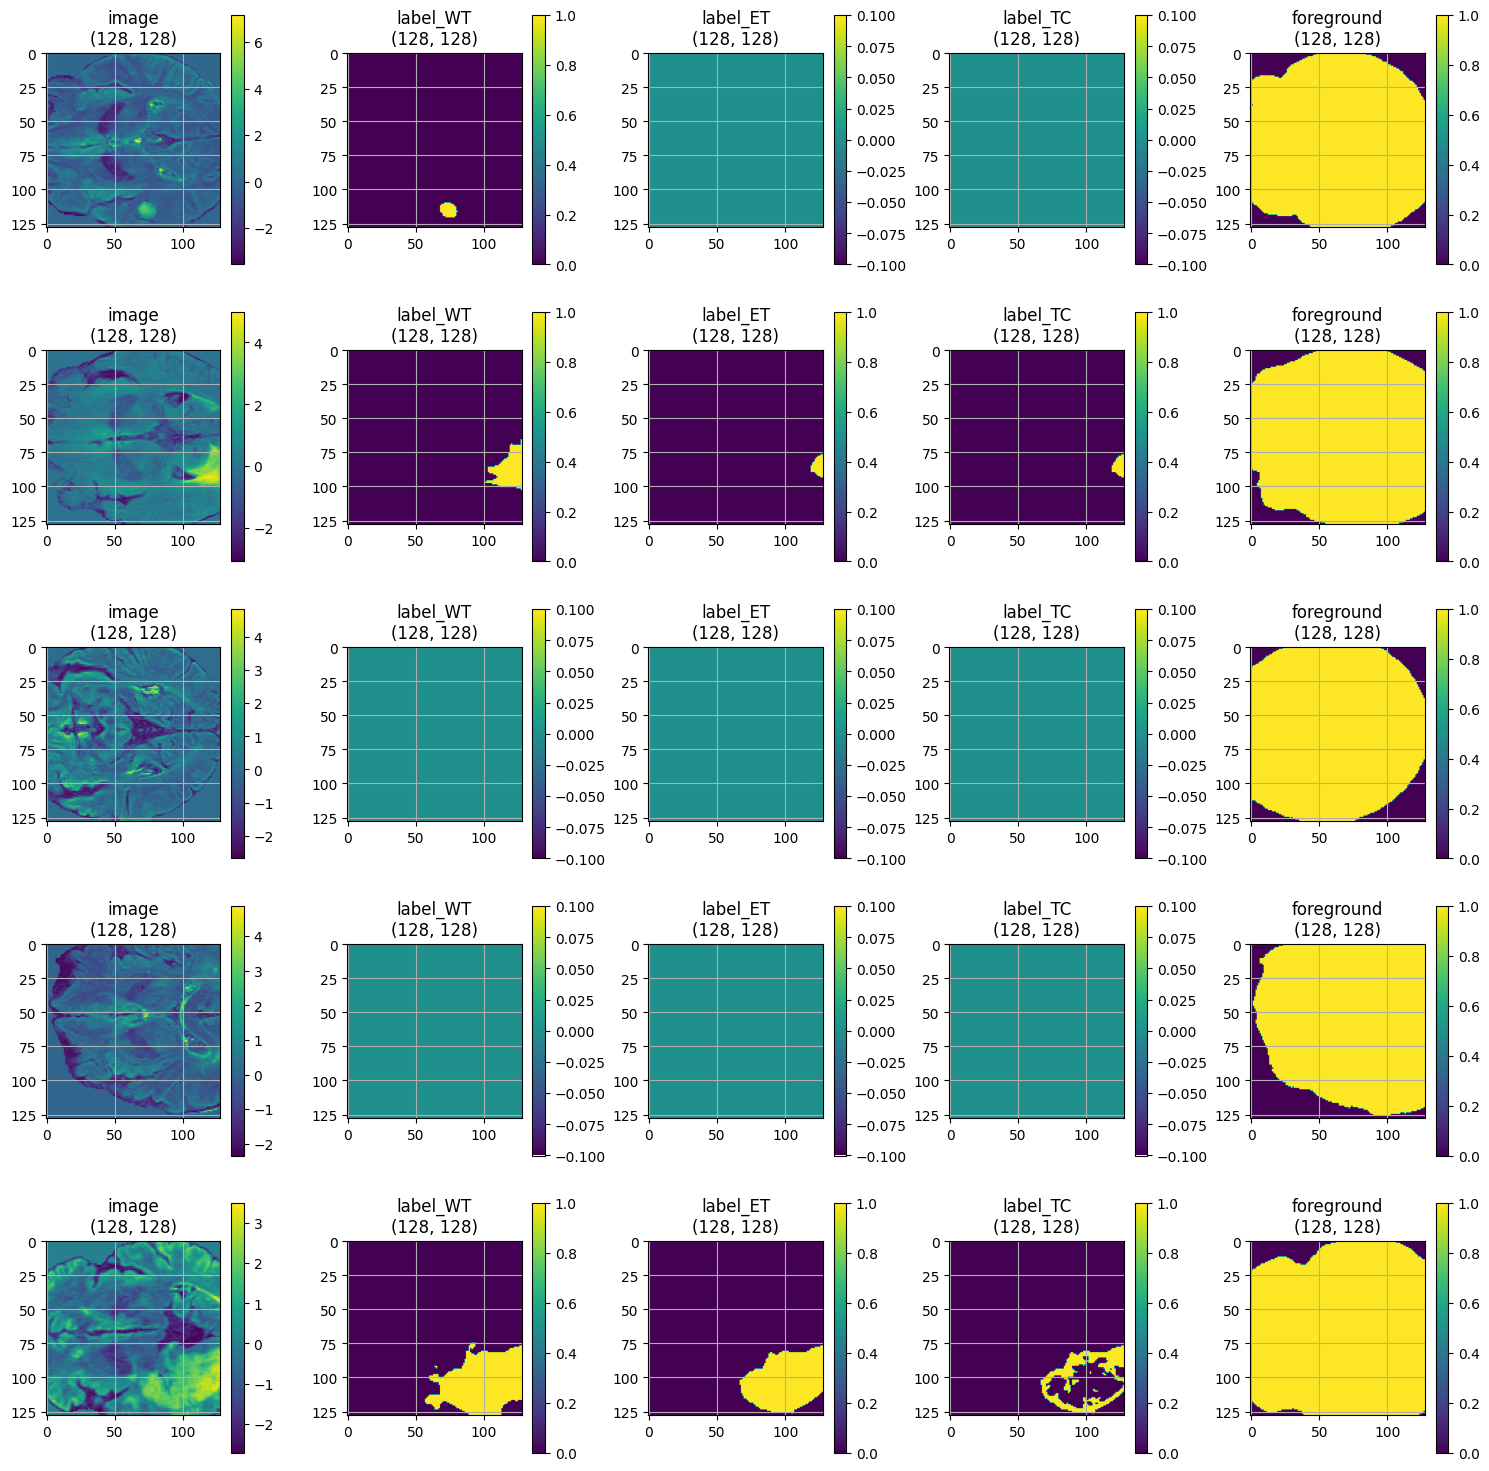

In [38]:
to_imshow = []
for idx in np.random.randint(0, len(val_data), size=5):
    data_ = val_data.__getitem__(idx)
    data_1 = transform_imgs(data_, label_regions=['WT', 'ET', 'TC'])
    to_imshow.append(data_1)

imshows(to_imshow)

Display Image and Label Pairs before and after CropForeground (Test)

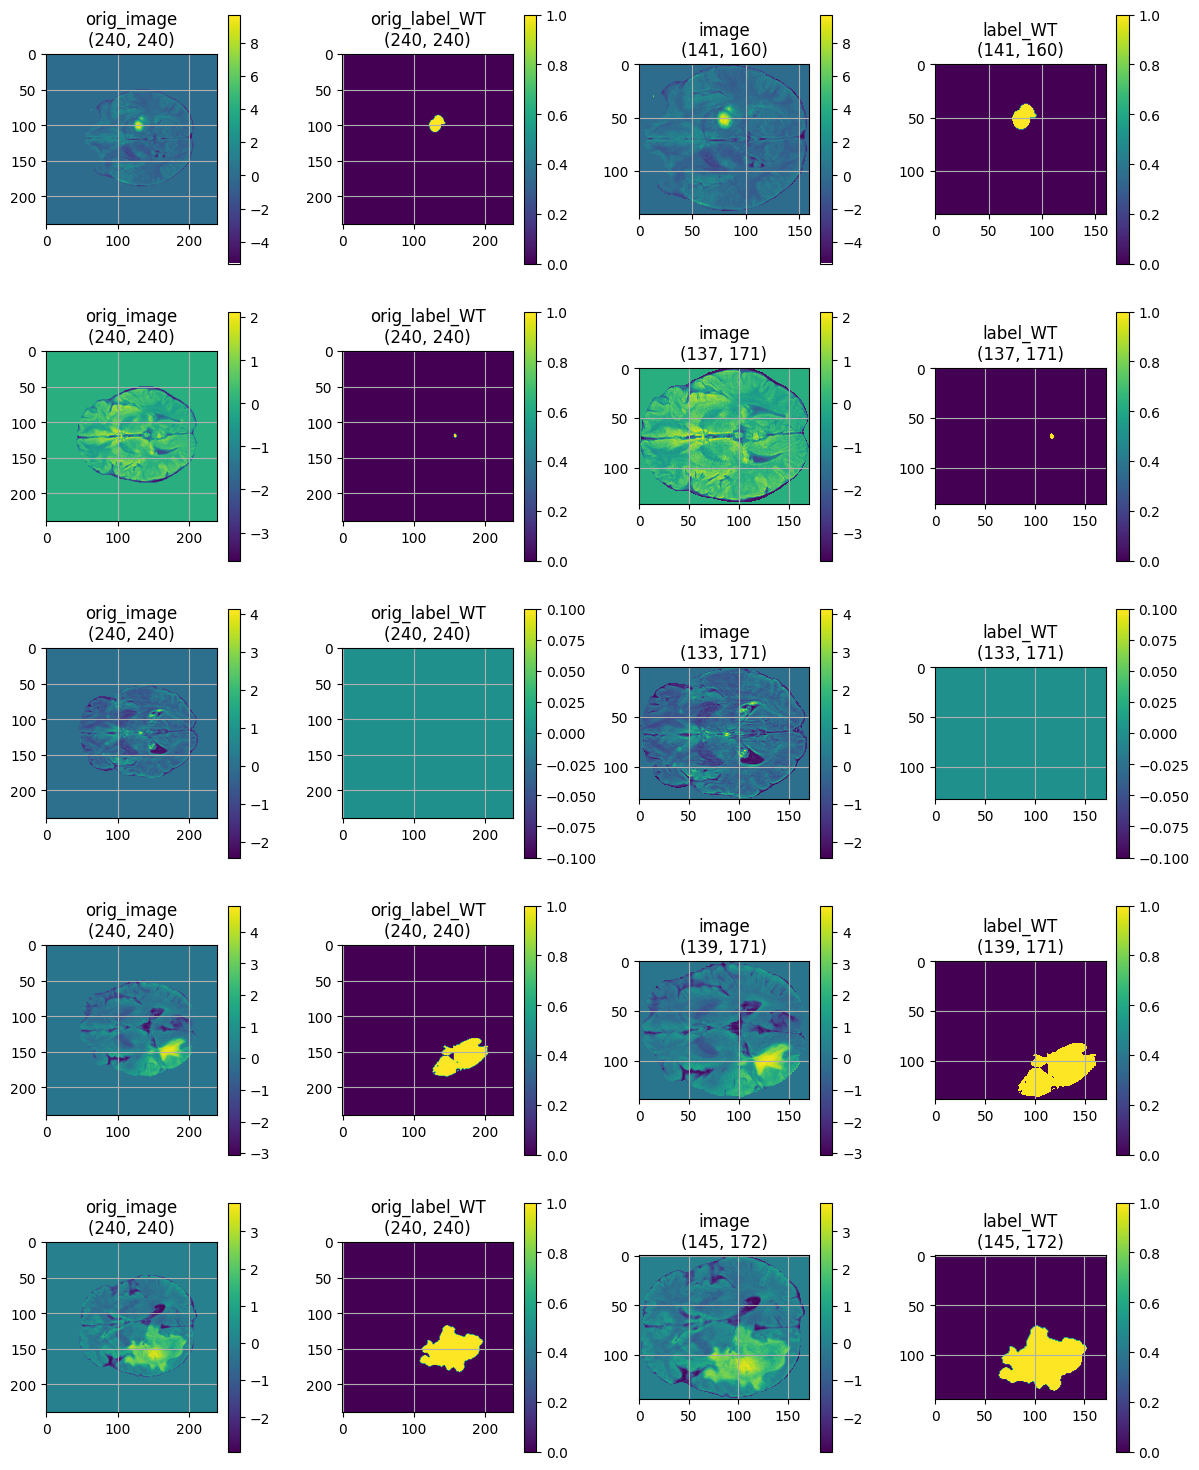

In [27]:
to_imshow = []
for idx in np.random.randint(0, len(test_data), size=5):
    data_ = test_data.__getitem__(idx)
    #print(data_['orig_image'].shape)
    #print(data_['foreground_start_coord'], data_['foreground_end_coord'])
    #print(data_['image'].shape)
    #print('\n')
    depth = data_['image'].shape[-1] // 2
    data_1 = transform_imgs(data_, label_regions=['WT'], depth=depth)
    orig_depth = depth + data_['foreground_start_coord'][-1]
    data_2 = transform_imgs(data_, label_regions=['WT'],key='orig_',depth=orig_depth)
    data_2.update(data_1)
    to_imshow.append(data_2)

imshows(to_imshow)

Add the cropped out background back to the initially cropped brain regions \
(Inverse of CropForeground)

Whole image-> crop brain fg -> sliding windows prediction with window size=(128, 128, 128) -> add bg back to prediction

27
torch.Size([4, 240, 240, 155])
torch.Size([4, 139, 171, 137])
torch.Size([4, 240, 240, 155])
107
torch.Size([4, 240, 240, 155])
torch.Size([4, 123, 166, 138])
torch.Size([4, 240, 240, 155])
43
torch.Size([4, 240, 240, 155])
torch.Size([4, 127, 172, 137])
torch.Size([4, 240, 240, 155])
127
torch.Size([4, 240, 240, 155])
torch.Size([4, 143, 176, 140])
torch.Size([4, 240, 240, 155])
230
torch.Size([4, 240, 240, 155])
torch.Size([4, 137, 171, 136])
torch.Size([4, 240, 240, 155])


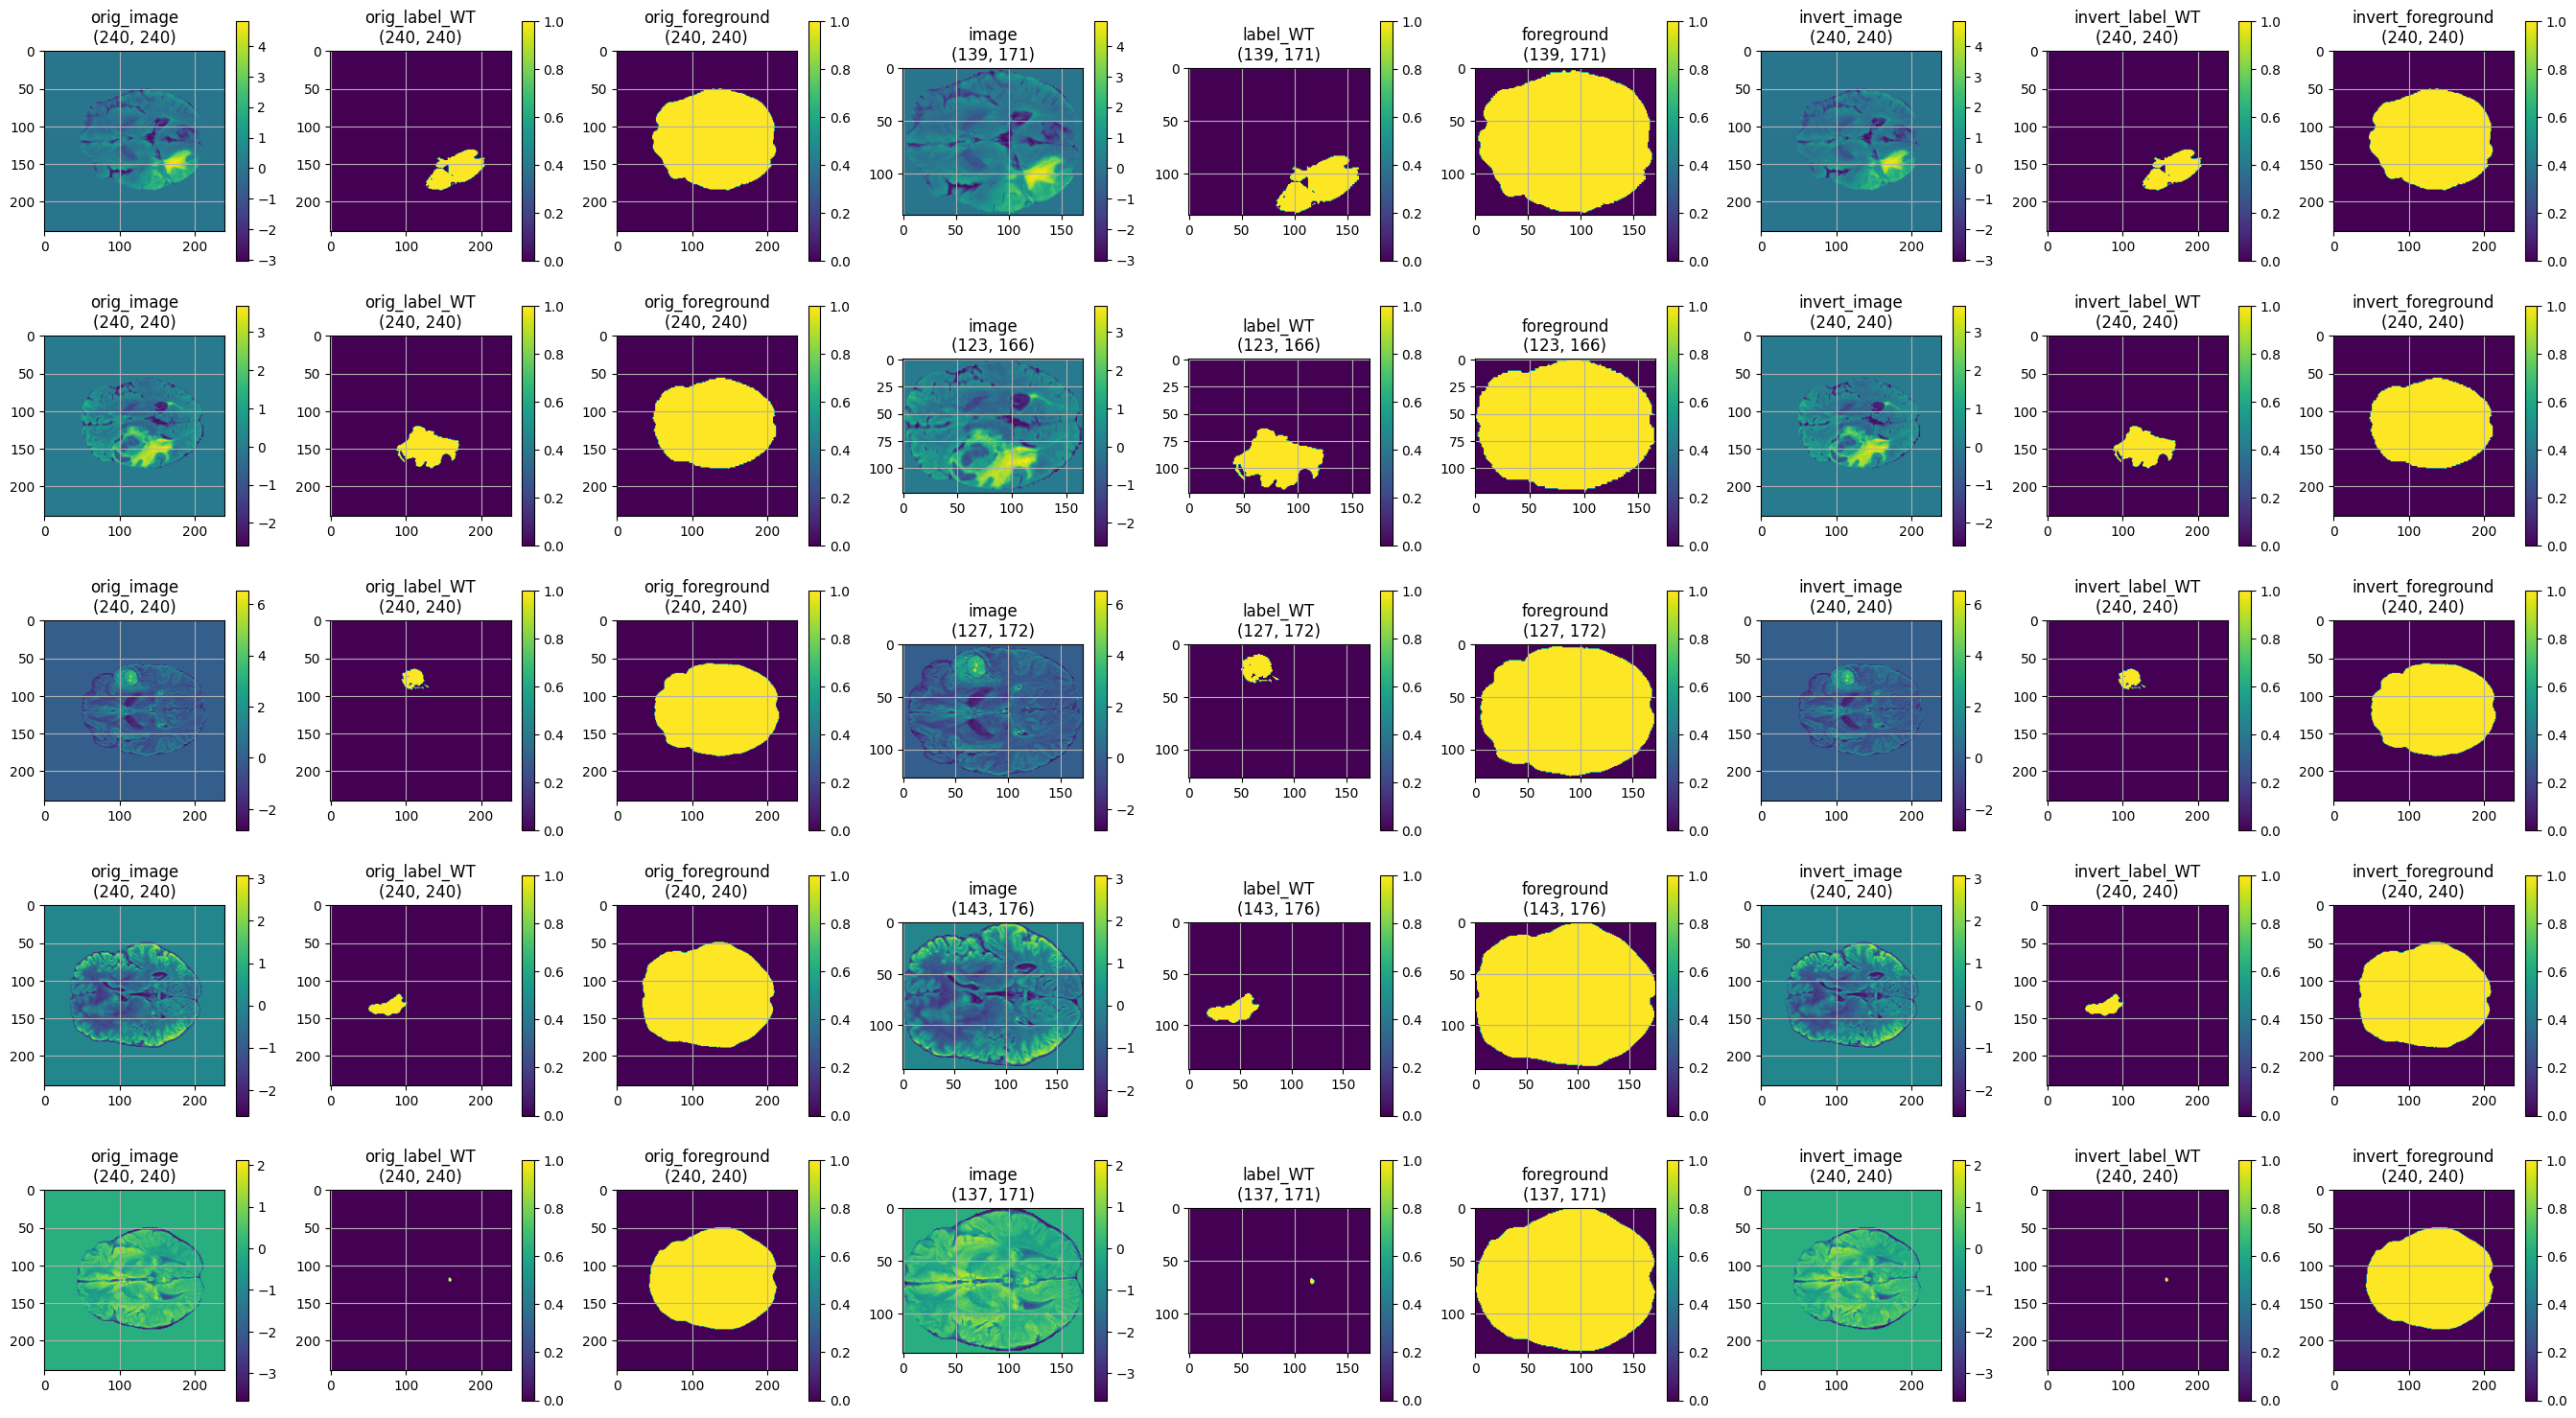

In [39]:

def add_background(orig_img:torch.Tensor, fg_crop:torch.Tensor, fg_start:Sequence[int], fg_end:Sequence[int]):
    img_with_bg = torch.zeros_like(orig_img)
    img_with_bg[:,fg_start[0]: fg_end[0], fg_start[1]: fg_end[1], fg_start[2]: fg_end[2]] = fg_crop
    assert torch.all(img_with_bg==orig_img)
    return img_with_bg

def add_backgrounds(data:dict):
    keys = ['image', 'mask', 'foreground']
    fg_start = data['foreground_start_coord']
    fg_end = data['foreground_end_coord']
    for key in keys:
        data[f"invert_{key}"] = add_background(data[f"orig_{key}"],data[key],fg_start,fg_end)
    return data

to_imshow = []
for idx in np.random.randint(0, len(test_data), size=5):
    data_ = test_data.__getitem__(idx)
    data_ = add_backgrounds(data_)
    print(idx)
    print(data_['orig_image'].shape) #original image
    print(data_['image'].shape) #CropForeground (background cropped out)
    print(data_['invert_image'].shape) #background added back
    depth = data_['image'].shape[-1] // 2
    orig_depth = depth + data_['foreground_start_coord'][-1]
    data_1 = transform_imgs(data_, label_regions=['WT'],key='orig_',depth=orig_depth)
    data_2 = transform_imgs(data_, label_regions=['WT'], depth=depth)
    data_1.update(data_2)
    data_3 = transform_imgs(data_, label_regions=['WT'],key='invert_',depth=orig_depth)
    data_1.update(data_3)
    to_imshow.append(data_1)

imshows(to_imshow)